### Iris Clustering 

In [ ]:
import pandas as pd 
from sklearn.datasets import load_iris 
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [ ]:
data = pd.DataFrame(iris.data,columns=iris.feature_names)
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
data['flower'] = iris.target 
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
from sklearn.cluster import KMeans
km_range= range(1,10)
errors = []
for i in km_range:
    cluster = KMeans(n_clusters=i)
    cluster.fit(data[['petal length (cm)', 'petal width (cm)']])
    errors.append(cluster.inertia_)

Text(0, 0.5, 'sum of squared error')

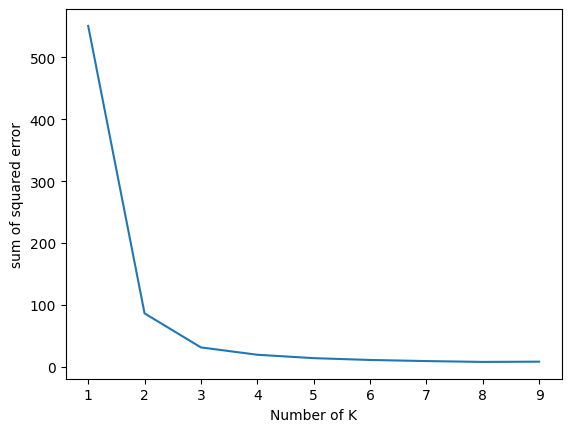

In [ ]:
plt.plot(km_range,errors)
plt.xlabel('Number of K')
plt.ylabel('sum of squared error')

In [ ]:
cluster_model = KMeans(n_clusters=3)
predicted_cluster = cluster_model.fit_predict(data[['petal length (cm)', 'petal width (cm)']])
data['Clusters'] = predicted_cluster

In [ ]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower,Clusters
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0


In [ ]:
data[45:55]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower,Clusters
45,4.8,3.0,1.4,0.3,0,0
46,5.1,3.8,1.6,0.2,0,0
47,4.6,3.2,1.4,0.2,0,0
48,5.3,3.7,1.5,0.2,0,0
49,5.0,3.3,1.4,0.2,0,0
50,7.0,3.2,4.7,1.4,1,2
51,6.4,3.2,4.5,1.5,1,2
52,6.9,3.1,4.9,1.5,1,2
53,5.5,2.3,4.0,1.3,1,2
54,6.5,2.8,4.6,1.5,1,2


In [ ]:
data[95:105]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower,Clusters
95,5.7,3.0,4.2,1.2,1,2
96,5.7,2.9,4.2,1.3,1,2
97,6.2,2.9,4.3,1.3,1,2
98,5.1,2.5,3.0,1.1,1,2
99,5.7,2.8,4.1,1.3,1,2
100,6.3,3.3,6.0,2.5,2,1
101,5.8,2.7,5.1,1.9,2,1
102,7.1,3.0,5.9,2.1,2,1
103,6.3,2.9,5.6,1.8,2,1
104,6.5,3.0,5.8,2.2,2,1


In [ ]:
data1 = data[data['Clusters'] == 0]
data2 = data[data['Clusters'] == 1]
data3 = data[data['Clusters'] == 2]

In [ ]:
cluster_model.cluster_centers_

array([[1.462     , 0.246     ],
       [5.59583333, 2.0375    ],
       [4.26923077, 1.34230769]])

Text(0, 0.5, 'petal width (cm)')

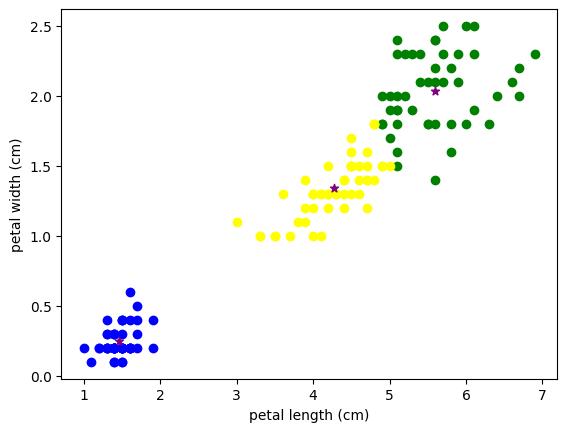

In [ ]:
plt.scatter(data1['petal length (cm)'],data1['petal width (cm)'],color='blue')
plt.scatter(data2['petal length (cm)'],data2['petal width (cm)'],color='green')
plt.scatter(data3['petal length (cm)'],data3['petal width (cm)'],color='yellow')
plt.scatter(cluster_model.cluster_centers_[:,0],cluster_model.cluster_centers_[:,1],marker='*',color='purple')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
